In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid, solve_ivp
from scipy.interpolate import interp1d, CubicSpline
from scipy.optimize import root_scalar

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 4. Modelos sin parámetros ajustables

Se presenta el uso de modelos sin parámetros ajustables, para evaluar la conversión en reactores reales.

## 4.1 Definiciones de Mezclado

### 4.1.1 Macromezclado

Mezclado a escalas macro, i.e., a gran escala dentro del reactor (Convección)

- Transporte de los paquetes de fluido entre distintas zonas del reactor.

- Produce una distribución de tiempos de residencia (RTD), sin especificar las interacciones entre moléculas de distintas edades.

### 4.1.2 Micromezclado

Mezclado a escalas micro y meso, i.e., mezclado al nivel molecular (interdifusión) de las especies químicas. 

In [3]:
### batch model
def batch(t, C, C0, k, n):
    r_A = -k*C[0]**n
    return np.array([r_A])

### cstr model (function for root finding)
def cstr(C, t, C0, k, n):
    r_A = -k*C**n
    return C0-C + r_A*t

## 4.2 Modelo segregado

En el modelo segregado se considera que no hay intercambio molecular entre los paquetes de fluidos, i.e. cada paquete de fluido es un mini reactor batch. La composición de cada paquete de fluido será de acuerdo con el tiempo de residencia en el reactor real, dado por la curva RTD.

<center>

<img src="figures/images/modelo_0_segreg.png" style="width:800px" title="Seregation model">

***Figura 01. Esquema del modelo segregado.*** 

</center>

La composición promedio a la salida del reactor se obtiene como un promedio ponderado de las composiciones de los paquetes de fluido con sus tiempos de residencia, en donde la curva de ponderación es la curva RTD.

$$\bar{C}_{\mathrm{A}} = \int_{0}^{\infty} C_{\mathrm{A}}(t) \cdot E(t) dt$$

$$\bar{X}_{\mathrm{A}} = \int_{0}^{\infty} X_{\mathrm{A}}(t) \cdot E(t) dt$$


In [4]:
### Segregated reactor model: Xseg = ∫X(t)*E(t) dt
def segreg_model(t, X, E):
    if type(E) == CubicSpline:
        return CubicSpline(t, X*E(t)).integrate(0, t[-1])
    else:
        return trapezoid(X*E(t), t)

## 4.3 Modelo de Máximo Mezclado

En el modelo de máximo mezclado, los paquetes de fluido se mezclan tan pronto entran en el reactor. El mezclado se efectúa de acuerdo con la esperanza de vida de cada paquete y la curva RTD.

<center>

<img src="figures/images/modelo_0_maxmix.png" style="width:800px" title="Maximum mixedness model">

***Figura 02. Esquema del modelo de máximo mezclado.*** 

</center>

La composición promedio de paquetes de fluido con una esperanza de vida, $\lambda$,  en el reactor, está dada por:

$$\frac{dC_{\mathrm{A}}}{d\lambda} = -r_{\mathrm{A}} + \left(C_{\mathrm{A}} - C_{\mathrm{A}}^0\right) \cdot \frac{E(\lambda)}{1-F(\lambda)}$$

$$ \frac{dX}{d\lambda} = \frac{r_{\mathrm{A}}}{C_{\mathrm{A}}^0} + X \cdot \frac{E(\lambda)}{1-F(\lambda)}$$

In [5]:
### Maximum mixedness model
def maxmix_model(lam, C, C0, k, n, Efun, Ffun):
    E_lam = Efun(lam) # E(t) (RTD)
    F_lam = min(0.999, Ffun(lam)) # F(t)
    r_A = -k*C[0]**n
    return np.array([-r_A + (C[0] - C0) * E_lam/(1-F_lam)])

## 4.4 Ejemplos

### 4.4.1 Reacción de primer orden (Levenspiel)

    Levenspiel, Ex. 11.4

En un reactor, cuya curva RTD se puede construir a partir de los datos $t$ vs $C$ mostrados debajo, se lleva a cabo una reacción de descomposición en fase líquida:

$$\mathrm{A \rightarrow B}$$

$$-r_{\mathrm{A}} = k C_{\mathrm{A}}$$

$$k=0.307\,\text{min}^{-1}$$

Calcule la conversión en el reactor real, usando los modelos segregado y de máximo mezclado, y compare contra reactores ideales del mismo tamaño.

In [6]:
### Datos
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3

C0 = 1
k = 0.307 # 1/min
order=1

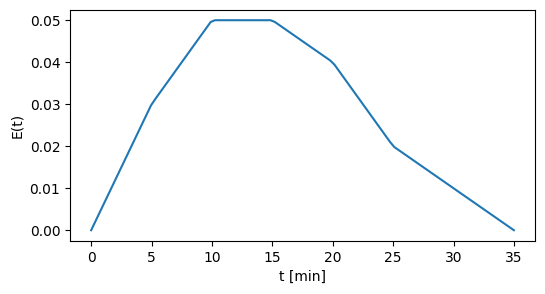

In [7]:
##############
Ei = interp1d(t, C/trapezoid(C,t)) # E(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0), kind='linear')
ti = np.linspace(t[0], t[-1], 100)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ti, Ei(ti))
ax.set_xlabel(r"t [min]")
ax.set_ylabel(r"E(t)")
plt.show()

In [8]:
### PFR: ODE solution (and conversion X)
t_span = (t[0], t[-1])
t_eval = np.linspace(t_span[0], t_span[-1], 100)
solpfr = solve_ivp(
    batch, 
    t_span=t_span, 
    y0=[C0],
    args=(C0, k, order),
    t_eval=t_eval
)
X = 1 - solpfr.y[0]/C0
Xpfr = X[-1]

### CSTR
solcstr = root_scalar(
    cstr,
    args=(t[-1], C0, k, 1),
    bracket=[0, C0]
)
Xcstr = 1 - solcstr.root/C0

### segregated reactor conversion, Xseg
Xseg = segreg_model(solpfr.t, X, Ei)

### maximum mixedness conversion
t_span = (t[-1], t[0])
t_eval = np.flip(t)
solmm = solve_ivp(
    maxmix_model,
    t_span=t_span,
    y0=[C0],
    args=(C0, k, order, Ei, Fi),
    t_eval=t_eval
)
Xmm = 1 - solmm.y[0][-1]/C0

models = ["PFR", "CSTR", "Seg.", "Max.Mix."]
xs = [Xpfr, Xcstr, Xseg, Xmm]
print("Conversion, X")
for model, x in zip(models, xs):
    print(f"{model:10}: {x:.4f}")

Conversion, X
PFR       : 1.0000
CSTR      : 0.9149
Seg.      : 0.9431
Max.Mix.  : 0.9427


### 4.4.2 Reacción de primer orden (Fogler)

    Fogler, Ex. 17.2

Calcule la conversión promedio en un reactor caracterizado por las mediciones RTD que se muestran debajo, para una reacción de primer orden en fase líquida:

$$\mathrm{A \rightarrow B}$$

$$-r_{\mathrm{A}} = k C_{\mathrm{A}}$$

$$k=0.1\,\text{min}^{-1}$$

Calcule la conversión en el reactor real, usando los modelos segregado y de máximo mezclado, y compare contra reactores ideales del mismo tamaño.

In [9]:
### Datos
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3

C0 = 1
k = 0.25 # 1/min
order=1

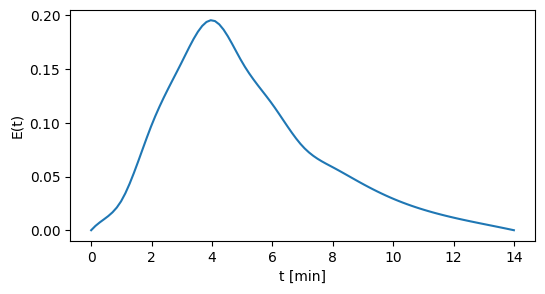

In [10]:
##############
Ei = CubicSpline(t, C/CubicSpline(t, C).integrate(t[0], t[-1]))   # E(t) spline
Fi = Ei.antiderivative()   # E(t) spline
ti = np.linspace(t[0], t[-1], 100)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ti, Ei(ti))
ax.set_xlabel(r"t [min]")
ax.set_ylabel(r"E(t)")
plt.show()

In [11]:
### PFR: ODE solution (and conversion X)
t_span = (t[0], t[-1])
t_eval = np.linspace(t_span[0], t_span[-1], 100)
solpfr = solve_ivp(
    batch, 
    t_span=t_span, 
    y0=[C0],
    args=(C0, k, order),
    t_eval=t_eval
)
X = 1 - solpfr.y[0]/C0
Xpfr = X[-1]

### CSTR
solcstr = root_scalar(
    cstr,
    args=(t[-1], C0, k, order),
    bracket=[0, C0]
)
Xcstr = 1 - solcstr.root/C0

### segregated reactor conversion, Xseg
Xseg = segreg_model(solpfr.t, X, Ei)

### maximum mixedness conversion
t_span = (t[-1], t[0])
t_eval = np.flip(t)
solmm = solve_ivp(
    maxmix_model,
    t_span=t_span,
    y0=[C0],
    args=(C0, k, order, Ei, Fi),
    t_eval=t_eval
)
Xmm = 1 - solmm.y[0][-1]/C0

models = ["PFR", "CSTR", "Seg.", "Max.Mix."]
xs = [Xpfr, Xcstr, Xseg, Xmm]
print("Conversion, X")
for model, x in zip(models, xs):
    print(f"{model:10}: {x:.4f}")

Conversion, X
PFR       : 0.9698
CSTR      : 0.7778
Seg.      : 0.6695
Max.Mix.  : 0.6692


### 4.4.3 CSTR no ideal, reacción de segundo orden (Fogler)

    Fogler, Ex. 17.4

En un reactor CSTR no-ideal con un volumen de $1000$ $\mathrm{dm^{3}}$, se lleva a cabo una reacción de dimerización de segundo orden:

$$\mathrm{2A \rightarrow B}$$

$$-r_{\mathrm{A}} = k C_{\mathrm{A}}^2$$

$$k=0.01\,\text{dm}^3.\text{mol}^{-1}.\text{min}^{-1}$$

El flujo volumétrico de alimentación al reactor es $25$ $\mathrm{dm^{3}.min^{-1}}$, y la concentración del reactivo a la entrada es $C_{\mathrm{A}}^0=8$ $\mathrm{mol.dm^{-3}}$.


Calcule la conversión en el reactor real, usando los modelos segregado y de máximo mezclado, y compare contra reactores ideales con las mismas condiciones operativas.

In [12]:
### Datos
N0 = 8 # mol/dm3
t = np.array([0, 5, 10, 15, 20, 30, 40, 50, 70, 100, 150, 200]) # min
X = np.array([0, 0.286, 0.444, 0.545, 0.615, 0.706, 0.762, 0.8, 0.848, 0.889, 0.923, 0.941])
C = N0 * (1-X)

# 2A --> B
C0 = 8 # mol/dm3
k = 0.01 # 1/min
order = 2

#
V = 1000 #dm3
Q = 25 # dm3/min
tau = V/Q # spatial time [min]
print(f"tau = {tau:.2f} min")

tau = 40.00 min


tr = 58.08 min


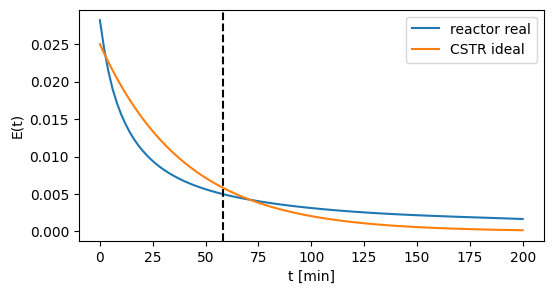

In [13]:
##############
Ei = CubicSpline(t, C/CubicSpline(t, C).integrate(t[0], t[-1]))   # E(t) spline
Fi = Ei.antiderivative()   # E(t) spline
tr = CubicSpline(t, t*Ei(t)).integrate(t[0], t[-1])  # mean residence time
print(f"tr = {tr:.2f} min")

ti = np.linspace(t[0], t[-1], 100)
fig, ax = plt.subplots(figsize=(6, 3))
cstrE = lambda t, tau: 1/tau * np.exp(-t/tau)
ax.plot(ti, Ei(ti), label='reactor real')
ax.plot(ti, cstrE(ti, tau), label='CSTR ideal')
ax.axvline(tr, ls='--', c='k')
ax.set_xlabel(r"t [min]")
ax.set_ylabel(r"E(t)")
ax.legend()
plt.show()

In [14]:
### PFR
solpfr =  solve_ivp(batch, t_span=(0, tau), y0=[C0], args=(C0, k, order))
Xpfr = 1.0 - solpfr.y[0][-1]/C0
### CSTR
solcstr = root_scalar(cstr, args=(tau, C0, k, order),bracket=[0, C0])
Xcstr = 1 - solcstr.root/C0

### segregated reactor conversion, Xseg
t_span = (t[0], t[-1])
t_eval = np.linspace(t_span[0], t_span[-1], 100)
solpfr = solve_ivp(
    batch, 
    t_span=t_span, 
    y0=[C0],
    args=(C0, k, order),
    t_eval=t_eval
)
X = 1 - solpfr.y[0]/C0
Xseg = segreg_model(solpfr.t, X, Ei)

### maximum mixedness conversion
t_span = (t[-1], t[0])
t_eval = np.flip(t)
solmm = solve_ivp(
    maxmix_model,
    t_span=t_span,
    y0=[C0],
    args=(C0, k, order, Ei, Fi),
    t_eval=t_eval
)
Xmm = 1 - solmm.y[0][-1]/C0

models = ["PFR", "CSTR", "Seg.", "Max.Mix."]
xs = [Xpfr, Xcstr, Xseg, Xmm]
print("Conversion, X")
for model, x in zip(models, xs):
    print(f"{model:10}: {x:.4f}")

Conversion, X
PFR       : 0.7614
CSTR      : 0.5758
Seg.      : 0.6674
Max.Mix.  : 0.6062


### 4.4.4 Reacciones complejas


    Fogler Ex. 17.6



**Reacciones:**

$$\begin{matrix*}[l]
\mathrm{A} + \mathrm{B} \xrightarrow[]{k_1} \mathrm{C} & \quad & r_{\mathrm{A}_1} = -k_{1} C_{\mathrm{A}} C_{\mathrm{B}} \\
\mathrm{A} \xrightarrow[]{k_2} \mathrm{D} & \quad & r_{\mathrm{A}_2} = -k_{2} C_{\mathrm{A}} \\
\mathrm{B + D} \xrightarrow[]{k_3} \mathrm{E} & \quad & r_{\mathrm{C}_3} = -k_{3} C_{\mathrm{B}} C_{\mathrm{D}} \\
\end{matrix*}$$

Tasas de reacción globales:
$$\begin{matrix*}[l]
r_{\mathrm{A}} = r_{\mathrm{A}_1} + r_{\mathrm{A}_2} \\
r_{\mathrm{B}} = r_{\mathrm{B}_1} + r_{\mathrm{B}_3} \\
r_{\mathrm{C}} = r_{\mathrm{C}_1} \\
r_{\mathrm{D}} = r_{\mathrm{D}_2} + r_{\mathrm{D}_3} \\
r_{\mathrm{E}} = r_{\mathrm{E}_3} \\
\end{matrix*}$$

In [15]:
def batch(t, C, k):
    cA, cB, cC, cD, cE = C
    k1, k2, k3 = k
    r_A = -k1*cA*cB - k2*cA
    r_B = -k1*cA*cB - k3*cB*cD
    r_C = k1*cA*cB
    r_D = k2*cA - k3*cB*cD
    r_E = k3*cB*cD
    dC_dt = np.array([r_A, r_B, r_C, r_D, r_E])
    return dC_dt

In [16]:
def maxmix(lam, C, C0, k, Efun, Ffun):
    E_lam = Efun(lam) # E(t) (RTD)
    F_lam = min(0.999, Ffun(lam)) # F(t)

    cA, cB, cC, cD, cE = C
    cA0, cB0, cC0, cD0, cE0 = C0
    k1, k2, k3 = k
    r_A = -k1*cA*cB - k2*cA
    r_B = -k1*cA*cB - k3*cB*cD
    r_C = k1*cA*cB
    r_D = k2*cA - k3*cB*cD
    r_E = k3*cB*cD

    dC_dt = np.array([
        -r_A + (cA - cA0) * E_lam/(1-F_lam), 
        -r_B + (cB - cB0) * E_lam/(1-F_lam), 
        -r_C + (cC - cC0) * E_lam/(1-F_lam), 
        -r_D + (cD - cD0) * E_lam/(1-F_lam), 
        -r_E + (cE - cE0) * E_lam/(1-F_lam)
    ])
    return dC_dt

##### Cinética reactor batch

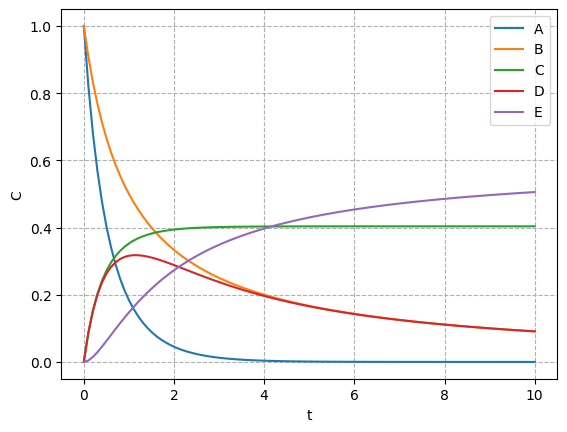

In [17]:
spcs = ['A', 'B', 'C', 'D', 'E']
C0 = [1.0, 1.0, 0.0, 0.0, 0.0]
k = [1, 1, 1]


t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol = solve_ivp(
    batch,
    t_span,
    y0=C0,
    args=(k,),
    t_eval=t_eval
)

fig, ax = plt.subplots()
for ii, spc in enumerate(spcs):
    ax.plot(sol.t, sol.y[ii], label=spc)
ax.set_xlabel(r't')
ax.set_ylabel(r'C')
ax.legend()
ax.grid(ls='--')
plt.show()


##### RTD monomodal

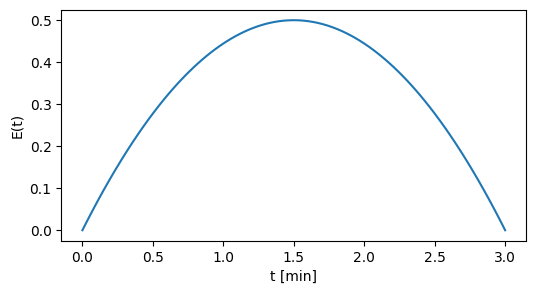

In [18]:
### Datos
t = np.array([0, 1.5, 3]) # min
C = np.array([0, 2, 0]) # g/m3

##############
Ei = interp1d(t, C/trapezoid(C,t)) # E(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0), kind='linear')

Ei = CubicSpline(t, C/CubicSpline(t, C).integrate(t[0], t[-1]))   # E(t) spline
Fi = Ei.antiderivative()   # E(t) spline

ti = np.linspace(t[0], t[-1], 100)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ti, Ei(ti))
ax.set_xlabel(r"t [min]")
ax.set_ylabel(r"E(t)")
plt.show()

**Modelo segregado**

In [19]:
t_span = (0, max(t))
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    args=(k,), 
    t_eval=t_eval
)
Cseg = []
for ii, spc in enumerate(spcs):
    cbar = trapezoid(sol.y[ii]*Ei(sol.t), sol.t)
    Cseg.append(cbar)
    print(f"C({spc}): {cbar:.4f}")

C(A): 0.1457
C(B): 0.4344
C(C): 0.3606
C(D): 0.2887
C(E): 0.2050


**Modelo máximo mezclado**

In [20]:
t_span = (max(t), 0)
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol = solve_ivp(
    maxmix,
    t_span,
    y0=C0,
    args=(C0, k, Ei, Fi),
    t_eval=t_eval
)
Cmm = []
for ii, spc in enumerate(spcs):
    cbar = sol.y[ii][-1]
    Cseg.append(cbar)
    print(f"C({spc}): {cbar:.4f}")

C(A): 0.1617
C(B): 0.4524
C(C): 0.3249
C(D): 0.2907
C(E): 0.2227


##### RTD bimodal

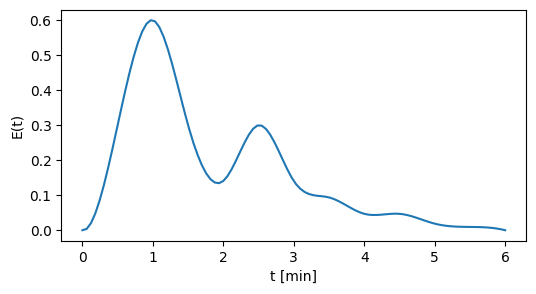

In [21]:
### Datos
t = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6]) # min
C = np.array([0, 0.32, 0.64, 0.32, 0.15, 0.32, 0.15, 0.1, 0.05, 0.05, 0.02, 0.01, 0.0]) # g/m3

##############
Ei = interp1d(t, C/trapezoid(C,t)) # E(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0), kind='linear')

Ei = CubicSpline(t, C/CubicSpline(t, C).integrate(t[0], t[-1]))   # E(t) spline
Fi = Ei.antiderivative()   # E(t) spline

ti = np.linspace(t[0], t[-1], 100)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ti, Ei(ti))
ax.set_xlabel(r"t [min]")
ax.set_ylabel(r"E(t)")
plt.show()

**Modelo segregado**

In [22]:
t_span = (0, max(t))
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol = solve_ivp(
    batch, 
    t_span, 
    y0=C0, 
    args=(k,), 
    t_eval=t_eval
)
Cseg = []
for ii, spc in enumerate(spcs):
    cbar = trapezoid(sol.y[ii]*Ei(sol.t), sol.t)
    Cseg.append(cbar)
    print(f"C({spc}): {cbar:.4f}")

C(A): 0.1386
C(B): 0.4164
C(C): 0.3629
C(D): 0.2778
C(E): 0.2206


**Modelo máximo mezclado**

In [23]:
t_span = (max(t), 0)
t_eval = np.linspace(t_span[0], t_span[-1], 100)
sol = solve_ivp(
    maxmix,
    t_span,
    y0=C0,
    args=(C0, k, Ei, Fi),
    t_eval=t_eval
)
Cmm = []
for ii, spc in enumerate(spcs):
    cbar = sol.y[ii][-1]
    Cseg.append(cbar)
    print(f"C({spc}): {cbar:.4f}")

C(A): 0.1591
C(B): 0.4453
C(C): 0.3051
C(D): 0.2862
C(E): 0.2496
